#**Projeto Chronos**
##CHALLENGE LOCAWEB 2026

Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# EC Sprint 3 — Machine Learning & Artificial Intelligence | Projeto Cronos

**O que o enunciado exige:**
1. AED: nulos, outliers, distribuições, correlações.
2. Engenharia de features: código + explicação de utilidade/vantagens/limitações.
3. Modelo simples e interpretável, validando a importância das variáveis criadas — **Data Leakage**.

**Decisão registrada:** o enunciado sugere regressão linear, mas o alvo (`KPI Violado?`) é binário — o par utilizado por metodologia foi de **regressão logística** (coeficientes lidos diretamente como odds ratio).

**Este notebook reaproveita a estrutura medalhão, utilizando de outros:**
- A AED aprofundada já feita em duas rodadas completas (`EDA_Completa` e `EDA_Complementar`) — utilizado nesse colab, apenas o recorte direto ao problema de classificação.
- As features causais já construídas na camada Gold (`gold_chamados_risco`).
- Os mesmos 3 folds de walk-forward usados nos Desafios 1 e 3, para consistência de comparação.

**Contraste direto com o CatBoost (Desafio 3):** com foco em prioridade (coeficientes legíveis), foi decidido utilizar a regressão logística com features categóricas de baixa cardinalidade (one-hot) e não utiliza o texto bruto, diferente do CatBoost, que processa tudo nativamente.

**Pré-requisito de arquivos no Drive:** este notebook depende só de `utils.py` — a função de preparação de features desta Sprint (`preparar_features_sklearn`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    aplicar_fold_por_timestamp, avaliar_classificador_raro, flag_low_volume_groups,
    preparar_features_sklearn, ajustar_logit_interpretavel,
)

logger = setup_logging('ml_sprint3')

## 1. Carga e filtro de elegibilidade

In [ ]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df = load_parquet_layer(gold_risco_path, logger=logger)
df['Aberto'] = pd.to_datetime(df['Aberto'])

df_elegivel = df[df['Entrou para KPI?'] == 'SIM'].copy()
df_elegivel['target'] = (df_elegivel['KPI Violado?'] == 'SIM').astype(int)
df_elegivel = df_elegivel.drop(columns=['grupo_baixo_volume'], errors='ignore')
df_elegivel['grupo_baixo_volume'] = flag_low_volume_groups(df_elegivel, 'Grupo designado', min_volume=100).astype(int)

logger.info('Universo elegível: %d chamados | Positivos: %d (%.2f%%)', len(df_elegivel), df_elegivel['target'].sum(), df_elegivel['target'].mean()*100)

2026-08-19 00:24:53 | INFO     | ml_sprint3 | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 37 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:ml_sprint3:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 37 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-08-19 00:24:53 | INFO     | ml_sprint3 | Universo elegível: 25156 chamados | Positivos: 238 (0.95%)


INFO:ml_sprint3:Universo elegível: 25156 chamados | Positivos: 238 (0.95%)


## 2. Análise Exploratória de Dados (AED) — recorte direto ao problema

**Nulos, outliers e distribuições já foram tratados em profundidade nas duas rodadas de EDA do projeto** (testes de qui-quadrado, Kruskal-Wallis, Cramér's V etc.). Recorte especificamente para a decisão de quais variáveis entram no modelo interpretável.

In [ ]:
resumo_nulos = df_elegivel[['Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Aberto por']].isna().mean().sort_values(ascending=False) * 100
resumo_nulos.rename('pct_nulos').to_frame()

,pct_nulos
Categoria,0.159008
Produto,0.155033
Subcategoria,0.151057
Grupo designado,0.000000
Aberto por,0.000000


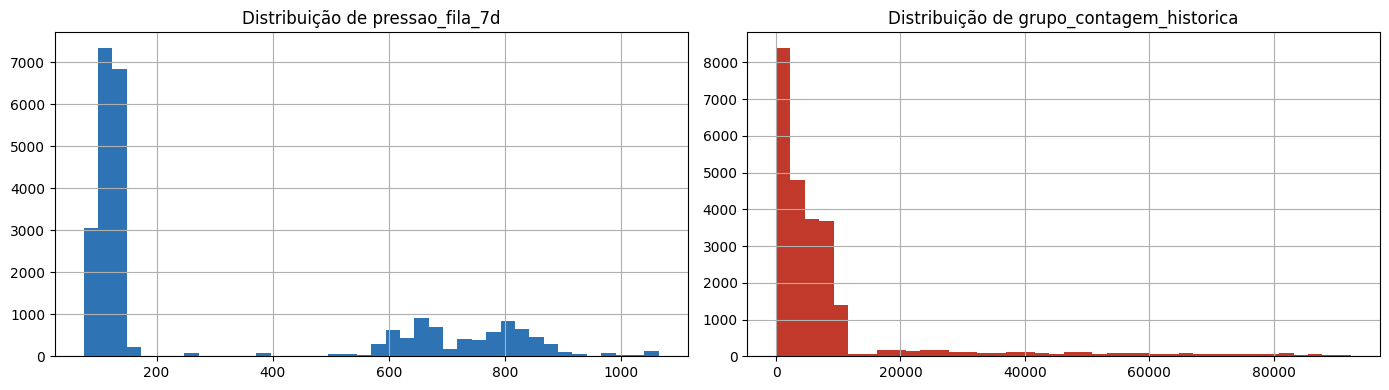

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_elegivel['pressao_fila_7d'].hist(bins=40, ax=axes[0], color='#2E74B5')
axes[0].set_title('Distribuição de pressao_fila_7d')

df_elegivel['grupo_contagem_historica'].hist(bins=40, ax=axes[1], color='#c0392b')
axes[1].set_title('Distribuição de grupo_contagem_historica')
plt.tight_layout()
plt.show()

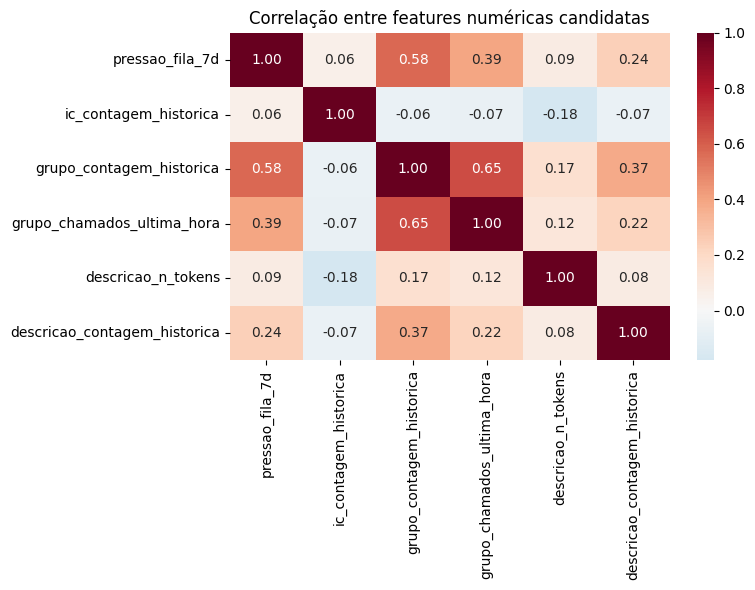

In [ ]:
features_numericas_aed = ['pressao_fila_7d', 'ic_contagem_historica', 'grupo_contagem_historica',
                          'grupo_chamados_ultima_hora', 'descricao_n_tokens', 'descricao_contagem_historica']
matriz_corr = df_elegivel[features_numericas_aed].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlação entre features numéricas candidatas')
plt.tight_layout()
plt.show()

## 3. Engenharia de Features — utilidade, vantagens e limitações de cada uma

Estas features já foram construídas na camada Gold (não são recriadas aqui) — a tabela documenta a decisão de cada uma, como o enunciado da disciplina exige.

In [ ]:
dados_features = [
    {
        'feature': 'pressao_fila_7d',
        'utilidade': 'Proxy de carga operacional do sistema no momento do chamado',
        'vantagem': 'Causal (só usa dados até o dia anterior); contextualiza o chamado no cenário operacional do momento',
        'limitacao': 'Vem do modelo agregado diário (Desafio 1), não do chamado individual — resolução temporal grosseira'
    },
    {
        'feature': 'grupo_contagem_historica',
        'utilidade': 'Volume histórico acumulado da equipe responsável',
        'vantagem': 'Causal; correlaciona-se com a variável mais forte da EDA (Grupo designado, Cramér\\s V 0,114)',
        'limitacao': 'Pode diluir a importância do Grupo designado bruto por sobreposição de informação'
    },
    {
        'feature': 'grupo_chamados_ultima_hora',
        'utilidade': 'Carga CORRENTE da equipe, não histórica',
        'vantagem': 'Captura sobrecarga momentânea, hipótese direta de risco operacional',
        'limitacao': 'Janela curta (1h) pode ser ruidosa para equipes de baixo volume'
    },
    {
        'feature': 'ic_contagem_historica',
        'utilidade': 'Recorrência de problema no mesmo ativo de infraestrutura',
        'vantagem': 'Causal; ativo com histórico de falhas é uma hipótese de risco tecnicamente sólida',
        'limitacao': 'Item de configuração bruto tem alta cardinalidade — só a versão agregada é usada, nunca o ID bruto'
    },
    {
        'feature': 'descricao_n_tokens',
        'utilidade': 'Verbosidade da descrição como proxy de complexidade do problema',
        'vantagem': 'Simples, sem exigir NLP; correlação plausível com problemas não-triviais',
        'limitacao': 'Proxy indireto — não confirma complexidade real, só o tamanho do texto'
    },
    {
        'feature': 'flag_categorizado',
        'utilidade': 'Sinaliza se o chamado passou por triagem/categorização humana',
        'vantagem': 'Evita usar Produto/Categoria brutos (63,6% nulos) mantendo o sinal de "foi categorizado ou não"',
        'limitacao': 'Fortemente confundida com Aberto por (Monitoramento vs. Manual) — redundância parcial'
    }
]

documentacao_features = pd.DataFrame(dados_features).set_index('feature')

(documentacao_features.style
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'vertical-align': 'top'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]}
    ])
)

,utilidade,vantagem,limitacao
feature,,,
pressao_fila_7d,Proxy de carga operacional do sistema no momento do chamado,Causal (só usa dados até o dia anterior); contextualiza o chamado no cenário operacional do momento,"Vem do modelo agregado diário (Desafio 1), não do chamado individual — resolução temporal grosseira"
grupo_contagem_historica,Volume histórico acumulado da equipe responsável,"Causal; correlaciona-se com a variável mais forte da EDA (Grupo designado, Cramér\s V 0,114)",Pode diluir a importância do Grupo designado bruto por sobreposição de informação
grupo_chamados_ultima_hora,"Carga CORRENTE da equipe, não histórica","Captura sobrecarga momentânea, hipótese direta de risco operacional",Janela curta (1h) pode ser ruidosa para equipes de baixo volume
ic_contagem_historica,Recorrência de problema no mesmo ativo de infraestrutura,Causal; ativo com histórico de falhas é uma hipótese de risco tecnicamente sólida,"Item de configuração bruto tem alta cardinalidade — só a versão agregada é usada, nunca o ID bruto"
descricao_n_tokens,Verbosidade da descrição como proxy de complexidade do problema,"Simples, sem exigir NLP; correlação plausível com problemas não-triviais","Proxy indireto — não confirma complexidade real, só o tamanho do texto"
flag_categorizado,Sinaliza se o chamado passou por triagem/categorização humana,"Evita usar Produto/Categoria brutos (63,6% nulos) mantendo o sinal de ""foi categorizado ou não""",Fortemente confundida com Aberto por (Monitoramento vs. Manual) — redundância parcial


## 4. Seleção de features para o modelo interpretável

**Decisão deliberada de simplificação, coerente com o objetivo de interpretabilidade:**
- Categóricas de baixa cardinalidade, via one-hot: `Prioridade`, `Grupo designado`, `Aberto por`, `turno_abertura`.
- Produto/Categoria/Subcategoria (63,6% nulos) ficam de fora do modelo linear — one-hot dessas variáveis explodiria a dimensionalidade com muita categoria rara, prejudicando a interpretabilidade. O sinal de cobertura permanece via `flag_categorizado`.
- Texto bruto (`descricao_limpa`) fica de fora — a regressão logística não processa texto nativamente como o CatBoost; As duas features numéricas derivadas do texto (`descricao_n_tokens`, `descricao_contagem_historica`) entram no lugar.

In [ ]:
CAT_FEATURES = ['Prioridade', 'Grupo designado', 'Aberto por', 'turno_abertura']
NUM_FEATURES = [
    'flag_categorizado', 'fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado',
    'fora_horario_comercial', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos',
    'descricao_n_tokens', 'descricao_contagem_historica', 'pressao_fila_7d',
    'ic_contagem_historica', 'ic_horas_desde_ultimo_chamado',
    'grupo_contagem_historica', 'grupo_chamados_ultima_hora', 'grupo_baixo_volume',
    'tem_incidente_pai', 'incidente_pai_contagem_historica',
]
TIME_COL, TARGET_COL = 'Aberto', 'target'

df_modelo = df_elegivel[CAT_FEATURES + NUM_FEATURES + [TARGET_COL, TIME_COL]].copy()
df_modelo[NUM_FEATURES] = df_modelo[NUM_FEATURES].fillna(0)
logger.info('Features do modelo: %d categóricas (one-hot) + %d numéricas.', len(CAT_FEATURES), len(NUM_FEATURES))


2026-08-19 00:24:54 | INFO     | ml_sprint3 | Features do modelo: 4 categóricas (one-hot) + 20 numéricas.


INFO:ml_sprint3:Features do modelo: 4 categóricas (one-hot) + 20 numéricas.


## 5. Nota sobre vazamento de dados

In [ ]:
COLUNAS_VAZAMENTO_CONHECIDAS = ['Resolvido', 'Encerrado', 'Duração', 'Código de fechamento', 'Solução', 'Status']
assert set(COLUNAS_VAZAMENTO_CONHECIDAS).isdisjoint(df_modelo.columns), 'Coluna pós-evento entrou no modelo!'

logger.info('Checagem de vazamento (colunas pós-evento): OK — nenhuma presente.')
logger.info(
    'Checagem de vazamento (encoding): o one-hot e o StandardScaler da Seção 6 são ajustados '
    'só dentro do treino de cada fold (preparar_features_sklearn) — nunca na base inteira.'
)


2026-08-19 00:24:54 | INFO     | ml_sprint3 | Checagem de vazamento (colunas pós-evento): OK — nenhuma presente.


INFO:ml_sprint3:Checagem de vazamento (colunas pós-evento): OK — nenhuma presente.


2026-08-19 00:24:54 | INFO     | ml_sprint3 | Checagem de vazamento (encoding): o one-hot e o StandardScaler da Seção 6 são ajustados só dentro do treino de cada fold (preparar_features_sklearn) — nunca na base inteira.


INFO:ml_sprint3:Checagem de vazamento (encoding): o one-hot e o StandardScaler da Seção 6 são ajustados só dentro do treino de cada fold (preparar_features_sklearn) — nunca na base inteira.


## 6. Folds walk-forward + treino da regressão logística, por fold

`class_weight='balanced'` — ajuste de função de perda pela classe rara sem gerar nenhum dado sintético.

In [ ]:
from sklearn.linear_model import LogisticRegression

folds = generate_expanding_folds(start_date=df_modelo[TIME_COL].min().strftime('%Y-%m-%d'), min_train_weeks=30, test_weeks=7, n_folds=3)

resultados_folds = {}
for f in folds:
    df_treino, df_teste = aplicar_fold_por_timestamp(df_modelo, TIME_COL, f)
    X_treino, X_teste, y_treino, y_teste, nomes_features = preparar_features_sklearn(
        df_treino, df_teste, CAT_FEATURES, NUM_FEATURES, TARGET_COL
    )

    modelo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    modelo.fit(X_treino, y_treino)
    y_score = modelo.predict_proba(X_teste)[:, 1]

    avaliacao = avaliar_classificador_raro(y_teste, y_score, k_list=[10, 20, 50])
    resultados_folds[f['fold']] = {'modelo': modelo, 'nomes_features': nomes_features, 'avaliacao': avaliacao, 'y_true': y_teste, 'y_score': y_score}

    logger.info('Fold %d: PR-AUC=%.4f [%.4f, %.4f] | ROC-AUC=%.4f', f['fold'], avaliacao['pr_auc'], avaliacao['pr_auc_ic_inferior'], avaliacao['pr_auc_ic_superior'], avaliacao['roc_auc_referencia'])

2026-08-19 00:24:58 | INFO     | ml_sprint3 | Fold 1: PR-AUC=0.0195 [0.0119, 0.0412] | ROC-AUC=0.7725


INFO:ml_sprint3:Fold 1: PR-AUC=0.0195 [0.0119, 0.0412] | ROC-AUC=0.7725


2026-08-19 00:25:02 | INFO     | ml_sprint3 | Fold 2: PR-AUC=0.0517 [0.0230, 0.1169] | ROC-AUC=0.8345


INFO:ml_sprint3:Fold 2: PR-AUC=0.0517 [0.0230, 0.1169] | ROC-AUC=0.8345


2026-08-19 00:25:05 | INFO     | ml_sprint3 | Fold 3: PR-AUC=0.0518 [0.0285, 0.1066] | ROC-AUC=0.7756


INFO:ml_sprint3:Fold 3: PR-AUC=0.0518 [0.0285, 0.1066] | ROC-AUC=0.7756


## 7. Interpretação dos coeficientes

In [ ]:
r3 = resultados_folds[3]
coeficientes = pd.DataFrame({
    'feature': r3['nomes_features'],
    'coeficiente': r3['modelo'].coef_[0],
})
coeficientes['odds_ratio'] = np.exp(coeficientes['coeficiente'])
coeficientes = coeficientes.sort_values('coeficiente', ascending=False)

print('Top 10 features que mais aumentam o risco:')
display(coeficientes.head(10))
print()
print('Top 10 features que mais reduzem o risco:')
display(coeficientes.tail(10))

Top 10 features que mais aumentam o risco:


,feature,coeficiente,odds_ratio
7,Grupo designado_Team06,1.675539,5.341672
8,Grupo designado_Team07,1.522173,4.582174
9,Grupo designado_Team08,1.301162,3.673562
13,Grupo designado_Team12,0.954644,2.597747
18,Aberto por_Manual,0.816198,2.261883
2,Grupo designado_Team01,0.808920,2.245482
4,Grupo designado_Team03,0.755554,2.128790
10,Grupo designado_Team09,0.721989,2.058524
16,Grupo designado_Team16,0.497500,1.644604
30,hora_cos,0.353998,1.424753



Top 10 features que mais reduzem o risco:


,feature,coeficiente,odds_ratio
35,pressao_fila_7d,-0.285050,0.751977
11,Grupo designado_Team10,-0.322547,0.724302
36,ic_contagem_historica,-0.336013,0.714614
17,Grupo designado_Team17,-0.377574,0.685522
39,grupo_chamados_ultima_hora,-0.424934,0.653813
19,Aberto por_Monitoramento,-0.838856,0.432205
5,Grupo designado_Team04,-1.134479,0.321590
6,Grupo designado_Team05,-1.445741,0.235572
14,Grupo designado_Team14,-2.318879,0.098384
15,Grupo designado_Team15,-2.648858,0.070732


### 7.1 Significância estatística — os coeficientes extremos são confiáveis?

Reajuste via `statsmodels.Logit` (não `sklearn`), que expõe p-valor e intervalo de confiança por coeficiente — ajustado uma única vez no treino completo do fold 3.

**Sobre robustez:** com ~17 equipes dividindo menos de 1% de positivos, é esperado que alguma equipe não tenha nenhum positivo no treino — nesse caso o ajuste clássico não converge (separação quase-completa).

A função tenta, em cascata: (1) ajuste clássico → (2) regularização L2/Ridge → (3) bootstrap de regressão logística regularizada, se até a regularização falhar ao calcular o erro-padrão. Qualquer um dos três sempre retorna coeficientes finitos.

In [ ]:
df_treino_f3, df_teste_f3 = aplicar_fold_por_timestamp(df_modelo, TIME_COL, folds[-1])

resultado_logit, nomes_logit, metodo_logit = ajustar_logit_interpretavel(
    df_treino_f3, CAT_FEATURES, NUM_FEATURES, TARGET_COL
)

if metodo_logit == 'classico':
    logger.info('Ajuste clássico convergiu normalmente — p-valores abaixo são inferência exata.')
elif metodo_logit == 'regularizado':
    logger.warning('Ajuste caiu para regularização L2/Ridge — p-valores abaixo são aproximados.')
else:
    logger.warning(
        'Ajuste caiu para bootstrap (provável múltiplas equipes sem nenhum positivo ao mesmo tempo) — '
        'coeficientes e p-valores vêm da distribuição empírica entre reamostragens, não de inferência analítica.'
    )

tabela_significancia = pd.DataFrame({
    'feature': nomes_logit,
    'coeficiente': resultado_logit.params,
    'p_valor': resultado_logit.pvalues,
    'ic_inferior': resultado_logit.conf_int()[:, 0],
    'ic_superior': resultado_logit.conf_int()[:, 1],
})
tabela_significancia['significativo_5%'] = tabela_significancia['p_valor'] < 0.05
tabela_significancia = tabela_significancia.sort_values('p_valor')

print(f'{tabela_significancia["significativo_5%"].sum()} de {len(tabela_significancia)} coeficientes são estatisticamente significativos (p<0,05).')
print()
print('Coeficientes de Grupo designado, especificamente (cruzar com grupo_baixo_volume ao interpretar):')
tabela_significancia[tabela_significancia['feature'].str.startswith('Grupo designado')]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 17 out of 40 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


2026-08-19 00:26:21 | WARNING  | ml_sprint3 | Ajuste caiu para bootstrap (provável múltiplas equipes sem nenhum positivo ao mesmo tempo) — coeficientes e p-valores vêm da distribuição empírica entre reamostragens, não de inferência analítica.


16 de 40 coeficientes são estatisticamente significativos (p<0,05).

Coeficientes de Grupo designado, especificamente (cruzar com grupo_baixo_volume ao interpretar):


,feature,coeficiente,p_valor,ic_inferior,ic_superior,significativo_5%
7,Grupo designado_Team07,1.093658,0.000000,0.320912,1.821668,True
5,Grupo designado_Team05,-1.592367,0.000000,-2.054425,-1.106604,True
4,Grupo designado_Team04,-0.095722,0.000000,-0.236544,-0.017723,True
13,Grupo designado_Team14,-2.455345,0.000000,-3.060150,-2.014639,True
14,Grupo designado_Team15,-0.308791,0.000000,-0.649015,-0.072958,True
11,Grupo designado_Team11,-0.356104,0.026667,-0.672883,-0.042136,True
16,Grupo designado_Team17,-0.459914,0.113333,-1.011806,0.154505,False
9,Grupo designado_Team09,0.235161,0.186667,-0.097084,0.555162,False
3,Grupo designado_Team03,0.365136,0.286667,-0.258796,0.933478,False
2,Grupo designado_Team02,-0.287567,0.293333,-0.730704,0.261403,False


## 8. Comparação consolidada entre os 3 folds

In [ ]:
linhas = []
for fold_num, r in resultados_folds.items():
    a = r['avaliacao']
    linhas.append({'fold': fold_num, 'pr_auc': a['pr_auc'], 'pr_auc_ic_inferior': a['pr_auc_ic_inferior'],
                    'pr_auc_ic_superior': a['pr_auc_ic_superior'], 'roc_auc': a['roc_auc_referencia'],
                    'precision_at_10': a['precision_at_10'], 'n_positivos_teste': a['n_positivos']})
df_resultados_ml = pd.DataFrame(linhas)
df_resultados_ml

,fold,pr_auc,pr_auc_ic_inferior,pr_auc_ic_superior,roc_auc,precision_at_10,n_positivos_teste
0,1,0.0195,0.0119,0.0412,0.7725,0.0,23
1,2,0.0517,0.0230,0.1169,0.8345,0.0,19
2,3,0.0518,0.0285,0.1066,0.7756,0.1,34


## 9. Comparação com o CatBoost

Números já obtidos na execução real do notebook de CatBoost, reproduzidos como contraste — não recalculados.

In [ ]:
comparacao_modelos = pd.DataFrame({
    'modelo': ['Regressão Logística (interpretável)', 'CatBoost (Desafio 3, produção)'],
    'PR-AUC médio (3 folds)': [round(df_resultados_ml['pr_auc'].mean(), 4), 0.1530],
    'ROC-AUC médio (3 folds)': [round(df_resultados_ml['roc_auc'].mean(), 4), 0.7838],
})
comparacao_modelos

,modelo,PR-AUC médio (3 folds),ROC-AUC médio (3 folds)
0,Regressão Logística (interpretável),0.041,0.7942
1,"CatBoost (Desafio 3, produção)",0.153,0.7838


## 10. Checagens de sanidade

In [ ]:
assert set(COLUNAS_VAZAMENTO_CONHECIDAS).isdisjoint(df_modelo.columns)
assert len(resultados_folds) == 3
for fold_num, r in resultados_folds.items():
    assert r['avaliacao']['n_positivos'] > 0, f'Fold {fold_num} sem positivos no teste!'
logger.info('Checagens de sanidade: OK.')

2026-08-19 00:26:21 | INFO     | ml_sprint3 | Checagens de sanidade: OK.


INFO:ml_sprint3:Checagens de sanidade: OK.


## 11. Resumo de execução

In [ ]:
resumo_execucao = f'''
EXECUÇÃO — Sprint 3 Machine Learning (Regressão Logística) — {pd.Timestamp.now(tz="UTC").isoformat()}
Universo elegível: {len(df_elegivel):,} chamados | Positivos: {df_elegivel["target"].sum()} ({df_elegivel["target"].mean()*100:.2f}%)

Resultado por fold:
{df_resultados_ml.to_string(index=False)}

Comparação com CatBoost:
{comparacao_modelos.to_string(index=False)}

Top 3 features que mais aumentam risco (fold 3): {coeficientes.head(3)["feature"].tolist()}
Top 3 features que mais reduzem risco (fold 3): {coeficientes.tail(3)["feature"].tolist()}
'''.strip()

print(resumo_execucao)

EXECUÇÃO — Sprint 3 Machine Learning (Regressão Logística) — 2026-08-19T00:26:21.237394+00:00
Universo elegível: 25,156 chamados | Positivos: 238 (0.95%)

Resultado por fold:
 fold  pr_auc  pr_auc_ic_inferior  pr_auc_ic_superior  roc_auc  precision_at_10  n_positivos_teste
    1  0.0195              0.0119              0.0412   0.7725              0.0                 23
    2  0.0517              0.0230              0.1169   0.8345              0.0                 19
    3  0.0518              0.0285              0.1066   0.7756              0.1                 34

Comparação com CatBoost:
                             modelo  PR-AUC médio (3 folds)  ROC-AUC médio (3 folds)
Regressão Logística (interpretável)                   0.041                   0.7942
     CatBoost (Desafio 3, produção)                   0.153                   0.7838

Top 3 features que mais aumentam risco (fold 3): ['Grupo designado_Team06', 'Grupo designado_Team07', 'Grupo designado_Team08']
Top 3 features que 